# PyKoopman: Appended Trajectories

> We use our training data to fit a DMD model by using time embeddings and multiple trajectories.

#### Imports

In [502]:
from ast import literal_eval

import matplotlib.pyplot as plt
import numpy as np
import numpy.random as rnd
import pykoopman as pk
from matrepr import mprint
from pydmd import DMD
from safetensors.torch import load_file

from learningdynamics.utils import safetensors_metadata_parser
from learningdynamics.dmd_dataset import (
    reshape_append_time,
    reshape_append_state,
)

In [503]:
# | hide
np.random.seed(42)  # for reproducibility
%matplotlib inline

#### Load data

The data is stored in 2D [states x length]

each block in the second dimension corresponds to a step for the n_traj

In [504]:
file_path = "../saved_weights/states.safetensors"

metadata = safetensors_metadata_parser(file_path=file_path)
NUM_LOOP_ITERATIONS = literal_eval(metadata["NUM_LOOP_ITERATIONS"])
NUM_TRAJECTORIES = literal_eval(metadata["NUM_TRAJECTORIES"])
NUM_STATES = literal_eval(metadata["NUM_STATES"])

data = load_file(file_path)

#### Update dataset

In [505]:
NUM_TRAJECTORIES = 1
NUM_LOOP_ITERATIONS = 6

NUM_DELAYS = 1

RANK = 10

In [506]:
t = np.arange(0, NUM_LOOP_ITERATIONS, 1)

#### Learn Koopman Operator

In [507]:
train_states = reshape_append_time(
    data["train_states"][:NUM_LOOP_ITERATIONS, :NUM_TRAJECTORIES, :]
)
test_states = reshape_append_time(
    data["test_states"][:NUM_LOOP_ITERATIONS, :NUM_TRAJECTORIES, :]
)
train_labels = data["train_labels"]
test_labels = data["test_labels"]
observables = pk.observables.TimeDelay(n_delays=NUM_DELAYS)

In [508]:
# Time shift data
X = train_states[:NUM_STATES, :-1].numpy()
Y = train_states[:NUM_STATES, 1:].numpy()

In [509]:
regressor = pk.regression.EDMD(svd_rank=RANK)
# regressor = pk.regression.EDMD()
# regressor = DMD(svd_rank=RANK)


dmd_model = pk.Koopman(observables=observables, regressor=regressor)
# dmd_model.fit(X.T, y=Y.T)
dmd_model.fit(X.T)

Koopman(observables=TimeDelay(n_delays=1), regressor=EDMD(svd_rank=10))

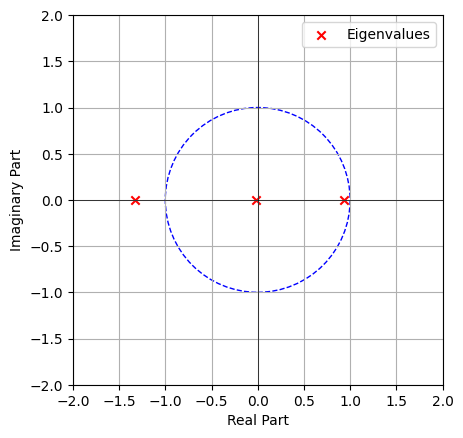

In [510]:
# Assuming koop_eigenvals is already defined
koop_eigenvals = np.linalg.eig(dmd_model.A)[0]

# Create the figure and axis
fig, ax = plt.subplots()

# Plot the unit circle
unit_circle = plt.Circle((0, 0), 1, color="b", fill=False, linestyle="--")
ax.add_artist(unit_circle)

# Plot the eigenvalues
ax.scatter(
    koop_eigenvals.real, koop_eigenvals.imag, color="r", marker="x", label="Eigenvalues"
)

# Set the axis limits
ax.set_xlim([-2, 2])
ax.set_ylim([-2, 2])

# Add grid, legend, and labels
ax.grid(True)
ax.axhline(0, color="black", linewidth=0.5)
ax.axvline(0, color="black", linewidth=0.5)
ax.set_aspect("equal", adjustable="box")
ax.set_xlabel("Real Part")
ax.set_ylabel("Imaginary Part")
ax.legend()

# Show the plot
plt.show()

In [511]:
SAMPLE = 0

/opt/conda/lib/python3.10/site-packages/pykoopman/koopman.py:285: ComplexWarning:

Casting complex values to real discards the imaginary part

/opt/conda/lib/python3.10/site-packages/pykoopman/koopman.py:290: ComplexWarning:

Casting complex values to real discards the imaginary part



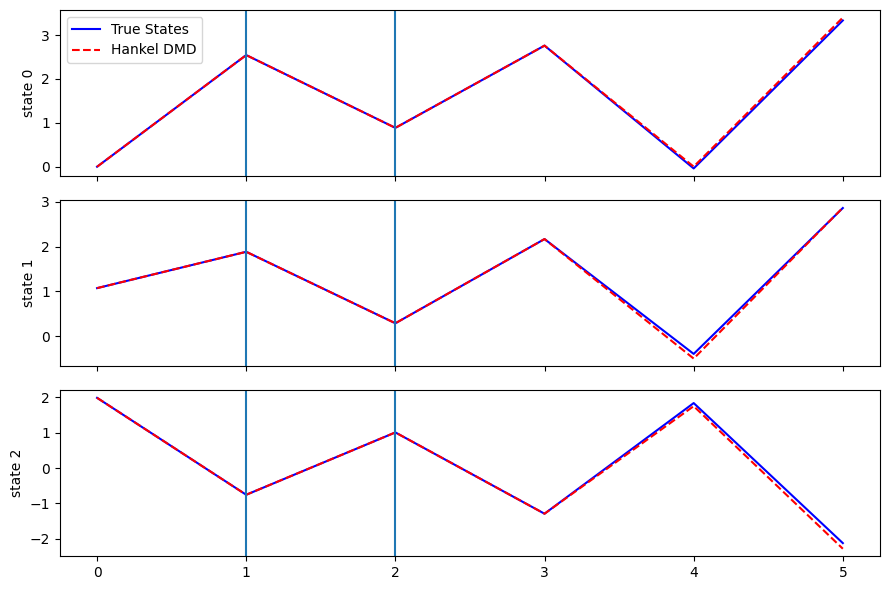

In [512]:
x0_td = train_states[
    :NUM_STATES,
    SAMPLE * NUM_LOOP_ITERATIONS : (SAMPLE * NUM_LOOP_ITERATIONS) + NUM_DELAYS + 1,
].T.numpy()
Xkoop = dmd_model.simulate(x0_td, n_steps=NUM_LOOP_ITERATIONS - 1 - NUM_DELAYS)
Xkoop = np.vstack([x0_td, Xkoop])

fig, axs = plt.subplots(NUM_STATES, 1, sharex=True, tight_layout=True, figsize=(9, 6))


for state_idx in range(0, NUM_STATES):
    axs[state_idx].plot(
        t,
        train_states[
            state_idx,
            SAMPLE * NUM_LOOP_ITERATIONS : SAMPLE * NUM_LOOP_ITERATIONS
            + NUM_LOOP_ITERATIONS,
        ],
        "-",
        color="b",
        label="True States",
    )
    axs[state_idx].plot(t, Xkoop[:, state_idx], "--r", label="Hankel DMD")
    axs[state_idx].set(ylabel=f"state {state_idx}")

for i in range(0, NUM_STATES):
    axs[i].axvline(x=t[NUM_DELAYS])
    axs[i].axvline(x=t[NUM_DELAYS + 1])
axs[0].legend()

/opt/conda/lib/python3.10/site-packages/pykoopman/koopman.py:285: ComplexWarning:

Casting complex values to real discards the imaginary part

/opt/conda/lib/python3.10/site-packages/pykoopman/koopman.py:290: ComplexWarning:

Casting complex values to real discards the imaginary part



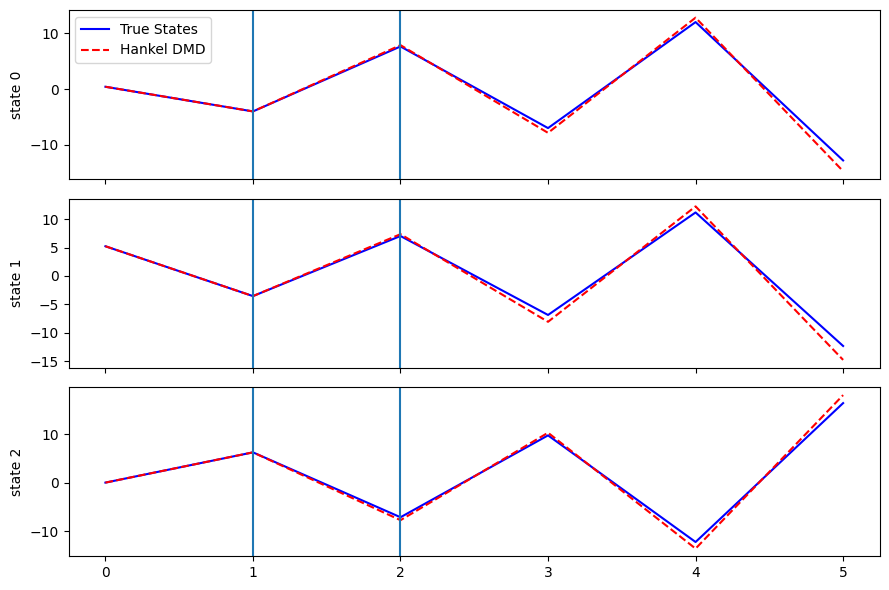

In [513]:
x0_td = test_states[
    :NUM_STATES,
    SAMPLE * NUM_LOOP_ITERATIONS : (SAMPLE * NUM_LOOP_ITERATIONS) + NUM_DELAYS + 1,
].T.numpy()
Xkoop = dmd_model.simulate(x0_td, n_steps=NUM_LOOP_ITERATIONS - 1 - NUM_DELAYS)
Xkoop = np.vstack([x0_td, Xkoop])

fig, axs = plt.subplots(NUM_STATES, 1, sharex=True, tight_layout=True, figsize=(9, 6))


for state_idx in range(0, NUM_STATES):
    axs[state_idx].plot(
        t,
        test_states[
            state_idx,
            SAMPLE * NUM_LOOP_ITERATIONS : SAMPLE * NUM_LOOP_ITERATIONS
            + NUM_LOOP_ITERATIONS,
        ],
        "-",
        color="b",
        label="True States",
    )
    axs[state_idx].plot(t, Xkoop[:, state_idx], "--r", label="Hankel DMD")
    axs[state_idx].set(ylabel=f"state {state_idx}")

for i in range(0, NUM_STATES):
    axs[i].axvline(x=t[NUM_DELAYS])
    axs[i].axvline(x=t[NUM_DELAYS + 1])
axs[0].legend()

In [514]:
import numpy as np
import plotly.express as px
from sklearn.decomposition import PCA, FastICA
from sklearn.manifold import TSNE
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
import umap
from scipy.spatial import procrustes
import pandas as pd

In [515]:
NUM_TRAJECTORIES = 5000
train_states = reshape_append_time(
    data["train_states"][:NUM_LOOP_ITERATIONS, :NUM_TRAJECTORIES, :]
)

In [516]:
def visualize_transformations_new(
    dmd_model,
    test_states,
    sample_indices,
    num_loop_iterations,
    num_delays,
    labels,
    num_states,
    lift,
    n_steps=1,
    view="2d",
    method="PCA",
):
    before_list = []
    predicted_list = []
    after_list = []

    labels_list = []

    if lift is False:
        num_delays = 0

    for sample_idx in sample_indices:
        x0_td = test_states[
            :num_states,
            sample_idx * num_loop_iterations : (sample_idx * num_loop_iterations)
            + num_delays
            + 1,
        ].numpy()

        # predicted = dmd_model.lamda @ before
        # for k in range(n_steps - 1):
        #     predicted = dmd_model.lamda @ predicted

        x1_td = test_states[
            :num_states,
            sample_idx * num_loop_iterations + n_steps : (
                sample_idx * num_loop_iterations
            )
            + num_delays
            + n_steps
            + 1,
        ].numpy()

        if lift is False:
            before = x0_td
            after = x1_td

        elif lift is True:
            before = dmd_model.psi(x0_td)
            after = dmd_model.psi(x1_td)

        before_list.append(before.T)

        # predicted_list.append(predicted.T)

        after_list.append(after.T)

        labels_list.extend([labels[sample_idx].item()] * before.shape[1])

    before_np_array = np.vstack(before_list)
    # predicted_np_array = np.vstack(predicted_list)
    after_np_array = np.vstack(after_list)

    def handle_complex_data(data, discard_imag=False):
        real = data.real
        complex = data.imag

        if discard_imag:
            return real
        else:
            return np.hstack([real, complex])

    before_np_array = handle_complex_data(before_np_array)
    # predicted_np_array = handle_complex_data(predicted_np_array)
    after_np_array = handle_complex_data(after_np_array)

    def reduce_dimensionality(data, method="PCA", labels=None, n_components=3):
        if method == "PCA":
            reducer = PCA(n_components=n_components)
        elif method == "ICA":
            reducer = FastICA(n_components=n_components)
        elif method == "t-SNE":
            reducer = TSNE(n_components=n_components, perplexity=30, n_iter=300)
        elif method == "LDA" and labels is not None:
            reducer = LDA(n_components=n_components)
            reduced_data = reducer.fit_transform(data, labels)
            return reduced_data
        elif method == "UMAP":
            reducer = umap.UMAP(n_components=n_components)
        reduced_data = reducer.fit_transform(data)
        return reduced_data

    n_components = 3 if view == "3d" else 2

    reduced_before_array = reduce_dimensionality(
        before_np_array,
        method=method,
        labels=labels_list,
        n_components=n_components,
    )
    reduced_predicted_array = reduce_dimensionality(
        after_np_array,
        method=method,
        labels=labels_list,
        n_components=n_components,
    )

    labels_str_list = [str(x) for x in labels_list]
    # Align the reduced results using Procrustes analysis
    mtx1, mtx2, disparity = procrustes(reduced_before_array, reduced_predicted_array)

    print("Disparity: ", disparity)

    if view == "3d":
        df_uplifted = pd.DataFrame(mtx1, columns=["x", "y", "z"])
        df_advanced = pd.DataFrame(mtx2, columns=["x", "y", "z"])
        df_uplifted["label"] = labels_str_list
        df_advanced["label"] = labels_str_list

        fig1 = px.scatter_3d(
            df_uplifted,
            x="x",
            y="y",
            z="z",
            size_max=1,
            color="label",
            color_discrete_sequence=px.colors.qualitative.T10,
            title="Pre",
        )
        fig2 = px.scatter_3d(
            df_advanced,
            x="x",
            y="y",
            z="z",
            size_max=1,
            color="label",
            color_discrete_sequence=px.colors.qualitative.T10,
            title="Predicted",
        )

        # Determine the axis limits and aspect ratio
        x_min = min(df_uplifted["x"].min(), df_advanced["x"].min())
        x_max = max(df_uplifted["x"].max(), df_advanced["x"].max())
        y_min = min(df_uplifted["y"].min(), df_advanced["y"].min())
        y_max = max(df_uplifted["y"].max(), df_advanced["y"].max())
        z_min = min(df_uplifted["z"].min(), df_advanced["z"].min())
        z_max = max(df_uplifted["z"].max(), df_advanced["z"].max())

        fig1.update_layout(
            scene=dict(
                # xaxis=dict(range=[x_min, x_max]),
                # yaxis=dict(range=[y_min, y_max]),
                # zaxis=dict(range=[z_min, z_max]),
                aspectmode="cube",
            )
        )
        fig2.update_layout(
            scene=dict(
                # xaxis=dict(range=[x_min, x_max]),
                # yaxis=dict(range=[y_min, y_max]),
                # zaxis=dict(range=[z_min, z_max]),
                aspectmode="cube",
            )
        )
    else:
        raise (NotImplementedError)
        # df_uplifted = pd.DataFrame(mtx1, columns=["x", "y"])
        # df_advanced = pd.DataFrame(mtx2, columns=["x", "y"])
        # df_uplifted["label"] = combined_labels_str
        # df_advanced["label"] = combined_labels_str

        # fig1 = px.scatter(
        #     df_uplifted,
        #     x="x",
        #     y="y",
        #     color="label",
        #     color_discrete_sequence=px.colors.qualitative.T10,
        #     title="Pre",
        # )
        # fig2 = px.scatter(
        #     df_advanced,
        #     x="x",
        #     y="y",
        #     color="label",
        #     color_discrete_sequence=px.colors.qualitative.T10,
        #     title="Predicted",
        # )

        # # Determine the axis limits
        # x_min = min(df_uplifted["x"].min(), df_advanced["x"].min())
        # x_max = max(df_uplifted["x"].max(), df_advanced["x"].max())
        # y_min = min(df_uplifted["y"].min(), df_advanced["y"].min())
        # y_max = max(df_uplifted["y"].max(), df_advanced["y"].max())

        # fig1.update_layout(
        #     xaxis=dict(scaleanchor="y", scaleratio=1, autorange=True),
        #     yaxis=dict(scaleanchor="x", scaleratio=1, autorange=True),
        # )
        # fig2.update_layout(
        #     xaxis=dict(scaleanchor="y", scaleratio=1, autorange=True),
        #     yaxis=dict(scaleanchor="x", scaleratio=1, autorange=True),
        # )

    fig1.update_traces(
        marker=dict(size=4, line=dict(width=0.2, color="DarkSlateGrey")),
        selector=dict(mode="markers"),
    )
    fig2.update_traces(
        marker=dict(size=4, line=dict(width=0.2, color="DarkSlateGrey")),
        selector=dict(mode="markers"),
    )
    fig1.show()
    fig2.show()


# Example usage
visualize_transformations_new(
    dmd_model,
    train_states,
    np.arange(NUM_TRAJECTORIES),
    NUM_LOOP_ITERATIONS,
    NUM_DELAYS,
    list(train_labels),
    num_states=NUM_STATES,
    n_steps=1,
    lift=False,
    view="3d",  # Change to "2d" for 2D visualization
    method="PCA",
)

Disparity:  0.3351573554732623
